

# Auto-generating Epochs metadata

This tutorial shows how to auto-generate metadata for `~mne.Epochs`, based on
events via `mne.epochs.make_metadata`.

We are going to use data from the `erp-core-dataset` (derived from
:footcite:`Kappenman2021`). This is EEG data from a single participant
performing an active visual task (Eriksen flanker task).

<div class="alert alert-info"><h4>Note</h4><p>If you wish to skip the introductory parts of this tutorial, you may jump
   straight to `tut-autogenerate-metadata-ern` after completing the data
   import and event creation in the
   `tut-autogenerate-metadata-preparation` section.</p></div>

This tutorial is loosely divided into two parts:

1. We will first focus on producing ERPs time-locked to the **visual
   stimulation**, conditional on response correctness and response time in
   order to familiarize ourselves with the `~mne.epochs.make_metadata`
   function.
2. After that, we will calculate ERPs time-locked to the **responses** – again,
   conditional on response correctness – to visualize the error-related
   negativity (ERN), i.e. the ERP component associated with incorrect
   behavioral responses.


## Preparation

Let's start by reading, filtering, and producing a simple visualization of the
raw data. The data is pretty clean and contains very few blinks, so there's no
need to apply sophisticated preprocessing and data cleaning procedures.
We will also convert the `~mne.Annotations` contained in this dataset to events
by calling `mne.events_from_annotations`.


In [1]:
# Authors: Richard Höchenberger <richard.hoechenberger@gmail.com>
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

In [2]:
import matplotlib.pyplot as plt

import mne

data_dir = mne.datasets.erp_core.data_path()
infile = data_dir / "ERP-CORE_Subject-001_Task-Flankers_eeg.fif"

raw = mne.io.read_raw(infile, preload=True)
raw.filter(l_freq=0.1, h_freq=40)
raw.plot(start=60)

# extract events
all_events, all_event_id = mne.events_from_annotations(raw)

Opening raw data file /home/jshen/mne_data/MNE-ERP-CORE-data/ERP-CORE_Subject-001_Task-Flankers_eeg.fif...
    Range : 0 ... 935935 =      0.000 ...   913.999 secs
Ready.
Reading 0 ... 935935  =      0.000 ...   913.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:    2.0s finished


Using qt as 2D backend.


QStandardPaths: wrong permissions on runtime directory /run/user/1000/, 0755 instead of 0700


Used Annotations descriptions: [np.str_('response/left'), np.str_('response/right'), np.str_('stimulus/compatible/target_left'), np.str_('stimulus/compatible/target_right'), np.str_('stimulus/incompatible/target_left'), np.str_('stimulus/incompatible/target_right')]


## Creating metadata from events

### The basics of ``make_metadata``

Now it's time to think about the time windows to use for epoching and
metadata generation. **It is important to understand that these time windows
need not be the same!** That is, the automatically generated metadata might
include information about events from only a fraction of the epochs duration;
or it might include events that occurred well outside a given epoch.

Let us look at a concrete example. In the Flankers task of the ERP CORE
dataset, participants were required to respond to visual stimuli by pressing
a button. We're interested in looking at the visual evoked responses (ERPs)
of trials with correct responses. Assume that based on literature
studies, we decide that responses later than 1500 ms after stimulus onset are
to be considered invalid, because they don't capture the neuronal processes
of interest here. We can approach this  in the following way with the help of
`mne.epochs.make_metadata`:



In [3]:
# metadata for each epoch shall include events from the range: [0.0, 1.5] s,
# i.e. starting with stimulus onset and expanding beyond the end of the epoch
metadata_tmin, metadata_tmax = 0.0, 1.5

# auto-create metadata:
# this also returns a new events array and an event_id dictionary. we'll see
# later why this is important
metadata, events, event_id = mne.epochs.make_metadata(
    events=all_events,
    event_id=all_event_id,
    tmin=metadata_tmin,
    tmax=metadata_tmax,
    sfreq=raw.info["sfreq"],
)

# let's look at what we got!
metadata

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right
0,response/right,NaN,0.000000,NaN,NaN,NaN,NaN
1,response/right,NaN,0.000000,NaN,NaN,NaN,NaN
2,stimulus/compatible/target_left,0.551758,NaN,0.000000,NaN,NaN,NaN
3,response/left,0.000000,NaN,0.997070,NaN,NaN,NaN
4,stimulus/compatible/target_left,0.434570,NaN,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...
797,response/left,0.000000,1.343750,NaN,NaN,NaN,0.917969
798,stimulus/incompatible/target_right,NaN,0.425781,1.416016,NaN,NaN,0.000000
799,response/right,1.392578,0.000000,0.990234,NaN,NaN,NaN
800,stimulus/compatible/target_left,0.402344,NaN,0.000000,NaN,NaN,NaN


### Specifying time-locked events

We can see that the generated table has 802 rows, each one corresponding to
an individual event in ``all_events``. The first column, ``event_name``,
contains the name of the respective event around which the metadata of that
specific column was generated – we'll call that the "time-locked event",
because we'll assign it time point zero.

The names of the remaining columns correspond to the event names specified in
the ``all_event_id`` dictionary. These columns contain floats; the values
represent the latency of that specific event in seconds, relative to
the time-locked event (the one mentioned in the ``event_name`` column).
For events that didn't occur within the given time window, you'll see
a value of ``NaN``, simply indicating that no event latency could be
extracted.

Now, there's a problem here. We want to investigate the visual ERPs
conditional on responses. But the metadata that was just created contains
one row for **every** event, including responses. While we **could** create
epochs for all events, allowing us to pass those metadata, and later subset
the created events, there's a more elegant way to handle this:
`~mne.epochs.make_metadata` has a ``row_events`` parameter that
allows us to specify for which events to create metadata **rows**, while
still creating **columns for all events** in the ``event_id`` dictionary.

Because the metadata, then, only pertains to a subset of our original events,
it's important to keep the returned ``events`` and ``event_id`` around for
later use when we actually create our epochs, to ensure that metadata,
events, and event descriptions stay in sync.



In [4]:
row_events = [
    "stimulus/compatible/target_left",
    "stimulus/compatible/target_right",
    "stimulus/incompatible/target_left",
    "stimulus/incompatible/target_right",
]

metadata, events, event_id = mne.epochs.make_metadata(
    events=all_events,
    event_id=all_event_id,
    tmin=metadata_tmin,
    tmax=metadata_tmax,
    sfreq=raw.info["sfreq"],
    row_events=row_events,
)

metadata

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right
2,stimulus/compatible/target_left,0.551758,NaN,0.000000,NaN,NaN,NaN
4,stimulus/compatible/target_left,0.434570,NaN,0.000000,NaN,NaN,NaN
6,stimulus/incompatible/target_right,NaN,0.508789,NaN,NaN,NaN,0.00000
8,stimulus/compatible/target_left,0.503906,NaN,0.000000,NaN,1.449219,NaN
10,stimulus/incompatible/target_left,0.542969,NaN,NaN,NaN,0.000000,NaN
...,...,...,...,...,...,...,...
792,stimulus/compatible/target_left,0.496094,NaN,0.000000,NaN,NaN,NaN
794,stimulus/compatible/target_left,NaN,1.437500,0.000000,NaN,1.465820,NaN
796,stimulus/incompatible/target_left,0.547852,NaN,NaN,NaN,0.000000,1.46582
798,stimulus/incompatible/target_right,NaN,0.425781,1.416016,NaN,NaN,0.00000


### Keeping only the first events of a group

The metadata now contains 400 rows – one per stimulation – and the same
number of columns as before. Great!

We have two types of responses in our data: ``response/left`` and
``response/right``. We would like to map those to "correct" and "incorrect".
To make this easier, we can ask `~mne.epochs.make_metadata` to generate an
entirely **new** column that refers to the first response observed during the
given time interval. This works by passing a subset of the
:term:`hierarchical event descriptors` (HEDs, inspired by
:footcite:`BigdelyShamloEtAl2013`) used to name events via the ``keep_first``
parameter. For example, in the case of the HEDs ``response/left`` and
``response/right``, we could pass ``keep_first='response'`` to generate a new
column, ``response``, containing the latency of the respective event. This
value represents the first (or, in this specific example: the only)
response, regardless of side (left or right). To indicate **which** event
type (here: response side) was matched, a second column named
``first_response`` is added. The values in this column are the event types
without the string used for matching, as it is already encoded as the column
name, i.e. in our example, we expect it to only contain ``'left'`` and
``'right'``.



<Axes: title={'center': 'Response Times (first response)'}, ylabel='Frequency'>

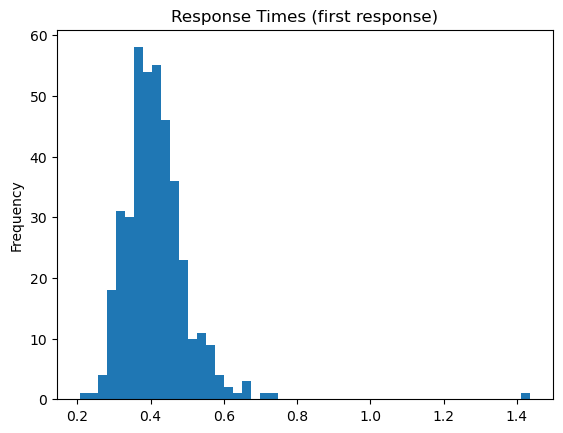

In [5]:
keep_first = "response"
metadata, events, event_id = mne.epochs.make_metadata(
    events=all_events,
    event_id=all_event_id,
    tmin=metadata_tmin,
    tmax=metadata_tmax,
    sfreq=raw.info["sfreq"],
    row_events=row_events,
    keep_first=keep_first,
)

# visualize response times regardless of side
metadata["response"].plot.hist(bins=50, title="Response Times (first response)")

The ``first_response`` column contains only ``"left"`` and ``"right"`` entries,
derived from the respective initial events ``"response/left"`` and
``"response/right"``:



In [6]:
print(metadata["first_response"])

2       left
4       left
6      right
8       left
10      left
       ...  
792     left
794    right
796     left
798    right
800     left
Name: first_response, Length: 400, dtype: object


For stimulus events, there are not only two, but **four** different types:
``stimulus/compatible/target_left``,
``stimulus/compatible/target_right``, ``stimulus/incompatible/target_left``,
and ``stimulus/incompatible/target_right``. What's more, because in the
present paradigm stimuli were presented in rapid succession, sometimes
multiple stimulus events occurred within the 1.5 second time window we used
to generate our metadata. See for example:



In [7]:
metadata.loc[
    metadata["stimulus/compatible/target_left"].notna()
    & metadata["stimulus/compatible/target_right"].notna(),
    :,
]

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right,response,first_response
24,stimulus/compatible/target_left,0.411133,NaN,0.000000,1.416016,NaN,NaN,0.411133,left
38,stimulus/compatible/target_right,NaN,0.454102,1.500000,0.000000,NaN,NaN,0.454102,right
66,stimulus/compatible/target_right,NaN,0.443359,1.466797,0.000000,NaN,NaN,0.443359,right
70,stimulus/compatible/target_left,0.400391,NaN,0.000000,1.499023,NaN,NaN,0.400391,left
186,stimulus/compatible/target_right,NaN,0.584961,1.449219,0.000000,NaN,NaN,0.584961,right
226,stimulus/compatible/target_left,0.421875,NaN,0.000000,1.450195,NaN,NaN,0.421875,left
232,stimulus/compatible/target_left,0.399414,NaN,0.000000,1.416016,NaN,NaN,0.399414,left
290,stimulus/compatible/target_left,0.316406,NaN,0.000000,1.499023,NaN,NaN,0.316406,left
316,stimulus/compatible/target_left,0.416992,NaN,0.000000,1.416992,NaN,NaN,0.416992,left
344,stimulus/compatible/target_left,0.386719,NaN,0.000000,1.450195,NaN,NaN,0.386719,left


Looking at the ``stimulus/compatible/target_left`` and
``stimulus/compatible/target_right`` columns, you will see that both always contain a
numerical value (one is always zero, the other is not). This is because both events
occurred within the time window of 1.5 seconds.

This can easily lead to confusion during later stages of processing, so let's
create a column for the first stimulus – which will always be the time-locked
stimulus, as our time interval starts at 0 seconds. We can pass a **list** of
strings to ``keep_first``.



In [8]:
keep_first = ["stimulus", "response"]
metadata, events, event_id = mne.epochs.make_metadata(
    events=all_events,
    event_id=all_event_id,
    tmin=metadata_tmin,
    tmax=metadata_tmax,
    sfreq=raw.info["sfreq"],
    row_events=row_events,
    keep_first=keep_first,
)

# all times of the time-locked events should be zero
assert all(metadata["stimulus"] == 0)

# the values in the new "first_stimulus" and "first_response" columns indicate
# which events were selected via "keep_first"
metadata[["first_stimulus", "first_response"]]

,first_stimulus,first_response
2,compatible/target_left,left
4,compatible/target_left,left
6,incompatible/target_right,right
8,compatible/target_left,left
10,incompatible/target_left,left
...,...,...
792,compatible/target_left,left
794,compatible/target_left,right
796,incompatible/target_left,left
798,incompatible/target_right,right


## Adding new columns to describe stimulation side and response correctness

Perfect! Now it's time to define which responses were correct and incorrect.
We first add a column encoding the side of stimulation, and then simply
check whether the response matches the stimulation side, and add this result
to another column.



In [9]:
metadata.loc[:, "stimulus_side"] = ""  # initialize column

# left-side stimulation
metadata.loc[
    metadata["first_stimulus"].isin(
        ["compatible/target_left", "incompatible/target_left"]
    ),
    "stimulus_side",
] = "left"

# right-side stimulation
metadata.loc[
    metadata["first_stimulus"].isin(
        ["compatible/target_right", "incompatible/target_right"]
    ),
    "stimulus_side",
] = "right"

# first assume all responses were incorrect, then mark those as correct where
# the stimulation side matches the response side
metadata["response_correct"] = False
metadata.loc[
    metadata["stimulus_side"] == metadata["first_response"], "response_correct"
] = True

metadata

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right,stimulus,response,first_stimulus,first_response,stimulus_side,response_correct
2,stimulus/compatible/target_left,0.551758,NaN,0.000000,NaN,NaN,NaN,0.0,0.551758,compatible/target_left,left,left,True
4,stimulus/compatible/target_left,0.434570,NaN,0.000000,NaN,NaN,NaN,0.0,0.434570,compatible/target_left,left,left,True
6,stimulus/incompatible/target_right,NaN,0.508789,NaN,NaN,NaN,0.00000,0.0,0.508789,incompatible/target_right,right,right,True
8,stimulus/compatible/target_left,0.503906,NaN,0.000000,NaN,1.449219,NaN,0.0,0.503906,compatible/target_left,left,left,True
10,stimulus/incompatible/target_left,0.542969,NaN,NaN,NaN,0.000000,NaN,0.0,0.542969,incompatible/target_left,left,left,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,stimulus/compatible/target_left,0.496094,NaN,0.000000,NaN,NaN,NaN,0.0,0.496094,compatible/target_left,left,left,True
794,stimulus/compatible/target_left,NaN,1.437500,0.000000,NaN,1.465820,NaN,0.0,1.437500,compatible/target_left,right,left,False
796,stimulus/incompatible/target_left,0.547852,NaN,NaN,NaN,0.000000,1.46582,0.0,0.547852,incompatible/target_left,left,left,True
798,stimulus/incompatible/target_right,NaN,0.425781,1.416016,NaN,NaN,0.00000,0.0,0.425781,incompatible/target_right,right,right,True


Count the number of correct and incorrect responses:



In [10]:
correct_response_count = metadata["response_correct"].sum()
print(
    f"Correct responses: {correct_response_count}\n"
    f"Incorrect responses: {len(metadata) - correct_response_count}"
)

Correct responses: 346
Incorrect responses: 54


## Creating ``Epochs`` with metadata, and visualizing ERPs

The metadata is ready. Now it's finally time to create our epochs!
We will assign the metadata directly on epochs creation
via the ``metadata`` parameter. Also, it is important to
remember to pass the ``events`` and ``event_id`` that were returned from
`~mne.epochs.make_metadata`, as we only created metadata for a subset of
our original events by passing ``row_events``. If we were to pass to "original"
values instead, the length of the metadata and the number of epochs would mismatch,
which would raise an error.



In [11]:
epochs_tmin, epochs_tmax = -0.1, 0.4  # epochs range: [-0.1, 0.4] s
reject = {"eeg": 250e-6}  # exclude epochs with strong artifacts
epochs = mne.Epochs(
    raw=raw,
    tmin=epochs_tmin,
    tmax=epochs_tmax,
    events=events,
    event_id=event_id,
    metadata=metadata,
    reject=reject,
    preload=True,
)

Adding metadata with 13 columns
400 matching events found


Setting baseline interval to [-0.099609375, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 400 events and 513 original time points ...
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['FP2']
    Rejecting  epoch based on EEG : ['FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['F8']
9 bad epochs dropped


You probably also noticed that 9 epochs were dropped because they exceeded our
rejection limits. This is another reason why it is important to assign the metadata on
epochs creation: the metadata will be updated automatically to reflect the actual
epochs that were kept.

Lastly, let's visualize the ERPs associated with the visual stimulation. We will only
consider trials with correct responses and produce three plots:
one for all correct responses, one for correct slow responses (response time slower
than 0.5 s), and one for correct fast responses (response time up to 0.5 s).



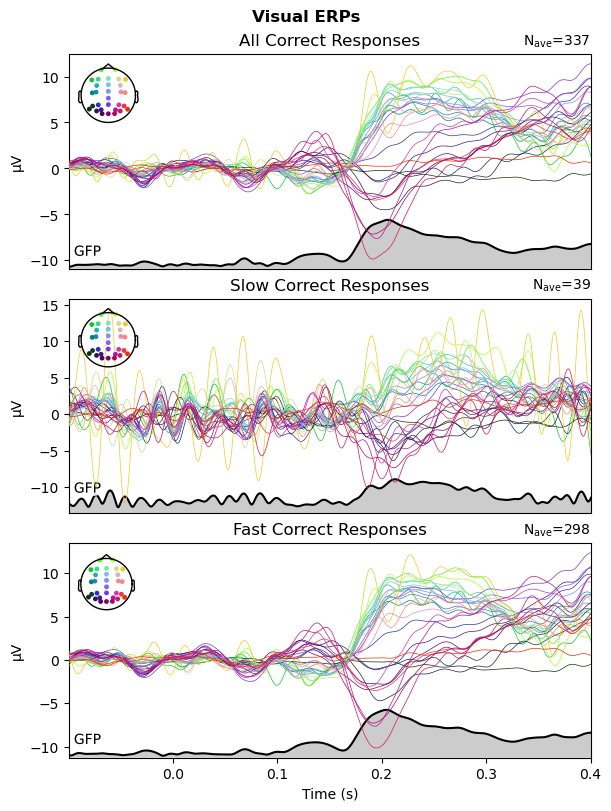

In [12]:
vis_erp = epochs["response_correct"].average()
vis_erp_slow = epochs["(response_correct) & (response > 0.5)"].average()
vis_erp_fast = epochs["(response_correct) & (response <= 0.5)"].average()

fig, ax = plt.subplots(3, figsize=(6, 8), layout="constrained")
vis_erp.plot(gfp=True, spatial_colors=True, axes=ax[0], show=False)
vis_erp_slow.plot(gfp=True, spatial_colors=True, axes=ax[1], show=False)
vis_erp_fast.plot(gfp=True, spatial_colors=True, axes=ax[2], show=False)

# Set titles
ax[0].set_title("All Correct Responses")
ax[1].set_title("Slow Correct Responses")
ax[2].set_title("Fast Correct Responses")
fig.suptitle("Visual ERPs", fontweight="bold")

# Turn of x axes for the first two plots
ax[0].xaxis.set_visible(False)
ax[1].xaxis.set_visible(False)

Aside from the fact that the data for the (much fewer) slow responses looks
noisier – which is entirely to be expected – not much of an ERP difference
can be seen.


## Applying the knowledge: visualizing the ERN component

In the following analysis, we will use the same dataset as above, but
we'll time-lock our epochs to the **response events,** not to the stimulus
onset. Comparing ERPs associated with correct and incorrect behavioral
responses, we should be able to see the error-related negativity (ERN) in
the difference wave.

Since we want to time-lock our analysis to responses, for the automated
metadata generation we'll consider events occurring up to 1500 ms before
the response trigger so we can be sure to capture the stimulation event as well.

We only wish to consider the **last** stimulus and response in each time
window: Remember that we're dealing with rapid stimulus presentations in
this paradigm; taking the last response (time point zero) and the last
stimulus (the one closest to the response) ensures that we actually create
the right stimulus-response pairings. We can achieve this by passing the
``keep_last`` parameter, which works exactly like ``keep_first`` we used
previously, only that it keeps the **last** occurrences of the specified
events and stores them in columns whose names start with ``last_``.



In [13]:
metadata_tmin, metadata_tmax = -1.5, 0
row_events = ["response/left", "response/right"]
keep_last = ["stimulus", "response"]

metadata, events, event_id = mne.epochs.make_metadata(
    events=all_events,
    event_id=all_event_id,
    tmin=metadata_tmin,
    tmax=metadata_tmax,
    sfreq=raw.info["sfreq"],
    row_events=row_events,
    keep_last=keep_last,
)

metadata

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right,stimulus,response,last_stimulus,last_response
0,response/right,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,None,right
1,response/right,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,None,right
3,response/left,0.000000,NaN,-0.551758,NaN,NaN,NaN,-0.551758,0.000000,compatible/target_left,left
5,response/left,-1.431641,NaN,-0.434570,NaN,NaN,NaN,-0.434570,-1.431641,compatible/target_left,left
7,response/right,NaN,0.000000,NaN,NaN,NaN,-0.508789,-0.508789,0.000000,incompatible/target_right,right
...,...,...,...,...,...,...,...,...,...,...,...
793,response/left,0.000000,-1.496094,-0.496094,NaN,NaN,NaN,-0.496094,0.000000,compatible/target_left,left
795,response/right,NaN,0.000000,-1.437500,NaN,NaN,NaN,-1.437500,0.000000,compatible/target_left,right
797,response/left,0.000000,-0.576172,NaN,NaN,-0.547852,NaN,-0.547852,0.000000,incompatible/target_left,left
799,response/right,-1.343750,0.000000,NaN,NaN,NaN,-0.425781,-0.425781,0.000000,incompatible/target_right,right


Exactly like in the previous example, we create new columns ``stimulus_side``
and ``response_correct``.



In [14]:
metadata.loc[:, "stimulus_side"] = ""  # initialize column

# left-side stimulation
metadata.loc[
    metadata["last_stimulus"].isin(
        ["compatible/target_left", "incompatible/target_left"]
    ),
    "stimulus_side",
] = "left"

# right-side stimulation
metadata.loc[
    metadata["last_stimulus"].isin(
        ["compatible/target_right", "incompatible/target_right"]
    ),
    "stimulus_side",
] = "right"

# first assume all responses were incorrect, then mark those as correct where
# the stimulation side matches the response side
metadata["response_correct"] = False
metadata.loc[
    metadata["stimulus_side"] == metadata["last_response"], "response_correct"
] = True

metadata

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right,stimulus,response,last_stimulus,last_response,stimulus_side,response_correct
0,response/right,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,None,right,,False
1,response/right,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,None,right,,False
3,response/left,0.000000,NaN,-0.551758,NaN,NaN,NaN,-0.551758,0.000000,compatible/target_left,left,left,True
5,response/left,-1.431641,NaN,-0.434570,NaN,NaN,NaN,-0.434570,-1.431641,compatible/target_left,left,left,True
7,response/right,NaN,0.000000,NaN,NaN,NaN,-0.508789,-0.508789,0.000000,incompatible/target_right,right,right,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,response/left,0.000000,-1.496094,-0.496094,NaN,NaN,NaN,-0.496094,0.000000,compatible/target_left,left,left,True
795,response/right,NaN,0.000000,-1.437500,NaN,NaN,NaN,-1.437500,0.000000,compatible/target_left,right,left,False
797,response/left,0.000000,-0.576172,NaN,NaN,-0.547852,NaN,-0.547852,0.000000,incompatible/target_left,left,left,True
799,response/right,-1.343750,0.000000,NaN,NaN,NaN,-0.425781,-0.425781,0.000000,incompatible/target_right,right,right,True


Now it's already time to epoch the data! When deciding upon the epochs
duration for this specific analysis, we need to ensure to include quite a bit
of signal from before and after the motor response. We also must be aware of
the fact that motor-/muscle-related signals will most likely be present
**before** the response button trigger pulse appears in our data, so the time
period close to the response event should not be used for baseline
correction. But at the same time, we don't want to use a baseline
period that extends too far away from the button event. The following values
seem to work quite well. Remember: time point zero is the response event.



In [15]:
epochs_tmin, epochs_tmax = -0.6, 0.4
baseline = (-0.4, -0.2)
reject = {"eeg": 250e-6}
epochs = mne.Epochs(
    raw=raw,
    tmin=epochs_tmin,
    tmax=epochs_tmax,
    baseline=baseline,
    reject=reject,
    events=events,
    event_id=event_id,
    metadata=metadata,
    preload=True,
)

Adding metadata with 13 columns
402 matching events found
Applying baseline correction (mode: mean)


0 projection items activated
Using data from preloaded Raw for 402 events and 1025 original time points ...
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['FP1', 'F7', 'FP2']
    Rejecting  epoch based on EEG : ['F7', 'F8', 'FC4']
    Rejecting  epoch based on EEG : ['FC3', 'F4', 'FC4']
    Rejecting  epoch based on EEG : ['FP1']
    Rejecting  epoch based on EEG : ['FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP2']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['FP2', 'F8']
    Rejecting  epoch based on EEG : ['FP1', 'F3', 'F7', 'FC3'

Let's do a final sanity check: we want to make sure that in every row, we
actually have a stimulus. We use ``epochs.metadata`` (and not ``metadata``)
because when creating the epochs, we passed the ``reject`` parameter, and
MNE-Python always ensures that ``epochs.metadata`` stays in sync with the
available epochs. During epochs creation, several epochs were dropped as they
exceeded the rejection limits.



In [16]:
epochs.metadata.loc[epochs.metadata["last_stimulus"].isna(), :]

,event_name,response/left,response/right,stimulus/compatible/target_left,stimulus/compatible/target_right,stimulus/incompatible/target_left,stimulus/incompatible/target_right,stimulus,response,last_stimulus,last_response,stimulus_side,response_correct
0,response/right,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,None,right,,False
1,response/right,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,None,right,,False


Bummer! It seems the very first two responses were recorded before the
first stimulus appeared: the values in the ``stimulus`` column are ``None``.
There is a very simple way to select only those epochs that **do** have a
stimulus (i.e., are not ``None``):



In [17]:
epochs = epochs["last_stimulus.notna()"]

Now it's time  to calculate the ERPs for correct  and incorrect responses.

For visualization, we'll only look at sensor ``FCz``, which is known to show
the ERN nicely in the given paradigm.



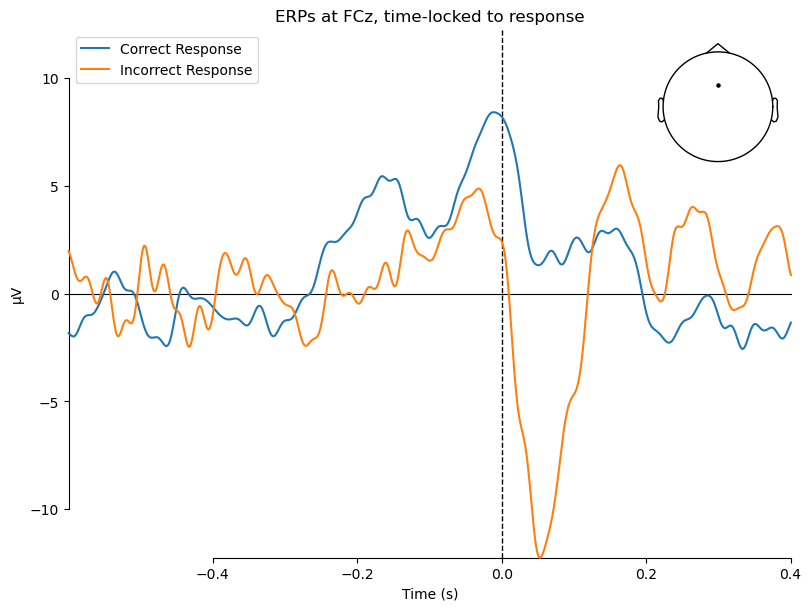

[<Figure size 800x600 with 2 Axes>]

In [18]:
resp_erp_correct = epochs["response_correct"].average()
resp_erp_incorrect = epochs["not response_correct"].average()

mne.viz.plot_compare_evokeds(
    {"Correct Response": resp_erp_correct, "Incorrect Response": resp_erp_incorrect},
    picks="FCz",
    show_sensors=True,
    title="ERPs at FCz, time-locked to response",
)

We'll also create a topoplot to get an
impression of the average scalp potentials measured in the first 100 ms after
an incorrect response.



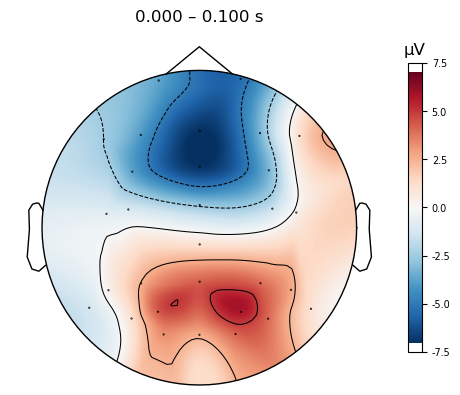

Text(0.5, 0.98, 'Mean topography after incorrect responses')

In [19]:
# topoplot of average field from time 0.0-0.1 s
fig = resp_erp_incorrect.plot_topomap(times=0.05, average=0.1, size=3)
fig.suptitle("Mean topography after incorrect responses", fontsize=14)

We can see a strong negative deflection immediately after incorrect
responses, compared to correct responses. The topoplot, too, leaves no doubt:
what we're looking at is, in fact, the ERN.

Some researchers suggest to construct the **difference wave** between ERPs for
correct and incorrect responses, as it more clearly reveals signal
differences, while ideally also improving the signal-to-noise ratio (under
the assumption that the noise level in "correct" and "incorrect" trials is
similar). Let's do just that and put it into a publication-ready
visualization.



Text(0.5, 0.98, 'ERN (Difference Wave)')

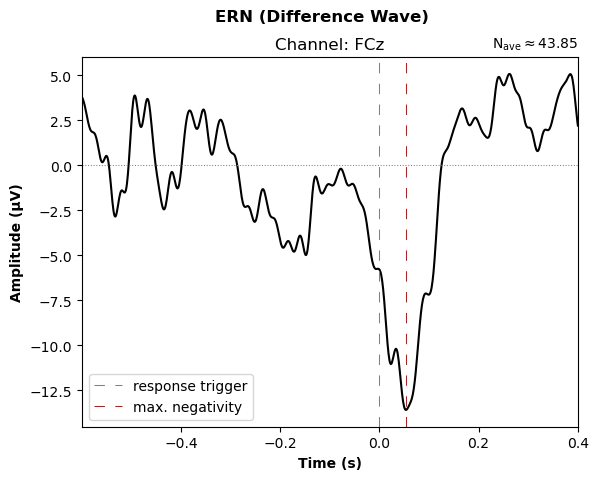

In [20]:
# difference wave: incorrect minus correct responses
resp_erp_diff = mne.combine_evoked(
    [resp_erp_incorrect, resp_erp_correct], weights=[1, -1]
)

fig, ax = plt.subplots()
resp_erp_diff.plot(picks="FCz", axes=ax, selectable=False, show=False)

# make ERP trace bolder
ax.lines[0].set_linewidth(1.5)

# add lines through origin
ax.axhline(0, ls="dotted", lw=0.75, color="gray")
ax.axvline(0, ls=(0, (10, 10)), lw=0.75, color="gray", label="response trigger")

# mark trough
trough_time_idx = resp_erp_diff.copy().pick("FCz").data.argmin()
trough_time = resp_erp_diff.times[trough_time_idx]
ax.axvline(trough_time, ls=(0, (10, 10)), lw=0.75, color="red", label="max. negativity")

# legend, axis labels, title
ax.legend(loc="lower left")
ax.set_xlabel("Time (s)", fontweight="bold")
ax.set_ylabel("Amplitude (µV)", fontweight="bold")
ax.set_title("Channel: FCz")
fig.suptitle("ERN (Difference Wave)", fontweight="bold")

## References
.. footbibliography::

